In [66]:
import pandas as pd
import yaml
import os


In [67]:
import os
os.getcwd()
os.listdir()

['functions.py',
 'main_dataset_tasks_anne.ipynb',
 '.DS_Store',
 'KPI_completion.ipynb',
 'KPI-duration_demogfx_rachel.py',
 'KPI-duration_rachel_updated.ipynb',
 'data_cleaning_beatriz.ipynb.backup',
 '__pycache__',
 '.ipynb_checkpoints',
 'data_loader_rachel.py',
 'demographics_rachel.ipynb']

In [68]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)

config

{'input_data': {'file1': '../data/raw/df_final_demo.txt',
  'file2': '../data/raw/df_final_experiment_clients.txt',
  'file3': '..//data/raw/df_final_web_data_pt_1.txt',
  'file4': '../data/raw/df_final_web_data_pt_2.txt'},
 'output_data': {'file5': '../data/clean/df_main_merge.csv',
  'file6': '../data/clean/df_visit_window.csv',
  'file7': '../data/clean/df_time_window.csv'}}

In [69]:
df_demo = pd.read_csv(config['input_data']['file1'])

df_demo.info()
df_demo.head()

<class 'pandas.DataFrame'>
RangeIndex: 70609 entries, 0 to 70608
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         70609 non-null  int64  
 1   clnt_tenure_yr    70595 non-null  float64
 2   clnt_tenure_mnth  70595 non-null  float64
 3   clnt_age          70594 non-null  float64
 4   gendr             70595 non-null  str    
 5   num_accts         70595 non-null  float64
 6   bal               70595 non-null  float64
 7   calls_6_mnth      70595 non-null  float64
 8   logons_6_mnth     70595 non-null  float64
dtypes: float64(7), int64(1), str(1)
memory usage: 4.8 MB


,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,U,2.0,45105.30,6.0,9.0
1,2304905,7.0,94.0,58.0,U,2.0,110860.30,6.0,9.0
2,1439522,5.0,64.0,32.0,U,2.0,52467.79,6.0,9.0
3,1562045,16.0,198.0,49.0,M,2.0,67454.65,3.0,6.0
4,5126305,12.0,145.0,33.0,F,2.0,103671.75,0.0,3.0


In [70]:
df_time_window = pd.read_csv(config['output_data']['file7'])
df_time_window.head()
df_time_window.shape

(154358, 17)

In [71]:
# Filter only clients who used the process
active_clients = df_time_window['client_id'].unique()

df_active_demo = df_demo[df_demo['client_id'].isin(active_clients)].copy()

In [72]:
# Clean gender

df_active_demo['gendr'] = df_active_demo['gendr'].replace({
    'M': 'Male',
    'F': 'Female',
    'U': 'Other/Unknown'
})

df_active_demo.head(50)

,client_id,clnt_tenure_yr,clnt_tenure_mnth,clnt_age,gendr,num_accts,bal,calls_6_mnth,logons_6_mnth
0,836976,6.0,73.0,60.5,Other/Unknown,2.0,45105.30,6.0,9.0
5,3727881,5.0,71.0,30.5,Other/Unknown,2.0,23915.60,0.0,3.0
6,272934,5.0,66.0,58.5,Other/Unknown,2.0,27021.42,2.0,5.0
7,388801,30.0,361.0,57.5,Male,5.0,522498.72,1.0,4.0
8,285619,30.0,369.0,67.5,Male,2.0,299388.72,3.0,6.0
9,8198645,15.0,189.0,54.5,Female,2.0,382303.83,6.0,9.0
10,8368822,8.0,100.0,34.5,Other/Unknown,2.0,75578.54,0.0,3.0
11,2537139,8.0,99.0,51.5,Other/Unknown,2.0,135940.68,6.0,9.0
13,2214073,16.0,193.0,62.5,Male,3.0,136818.03,6.0,9.0
14,2368987,5.0,71.0,54.5,Other/Unknown,2.0,44408.87,2.0,5.0


In [73]:
# Create age groups
bins = [0, 30, 50, 70, 100]
labels = ['<30', '30-50', '50-70', '70+']

df_active_demo['age_group'] = pd.cut(
    df_active_demo['clnt_age'],
    bins=bins,
    labels=labels
)

In [74]:
# Create tenure groups
bins = [0, 5, 10, 20, 50]
labels = ['0-5 yrs', '5-10 yrs', '10-20 yrs', '20+ yrs']

df_active_demo['tenure_group'] = pd.cut(
    df_active_demo['clnt_tenure_yr'],
    bins=bins,
    labels=labels
)

Who are the primary clients?

In [75]:
df_active_demo['gendr'].value_counts(normalize=True)
df_active_demo['age_group'].value_counts(normalize=True)
df_active_demo[['num_accts', 'bal']].describe()

,num_accts,bal
count,25408.000000,2.540800e+04
mean,2.273457,1.528833e+05
std,0.551158,3.020810e+05
min,1.000000,2.378944e+04
25%,2.000000,3.975314e+04
50%,2.000000,6.550728e+04
75%,2.000000,1.412966e+05
max,7.000000,8.137343e+06


Are they younger or older?

In [76]:
df_active_demo['clnt_age'].median()
df_active_demo['age_group'].value_counts(normalize=True)

age_group
50-70    0.399457
30-50    0.366710
<30      0.181997
70+      0.051836
Name: proportion, dtype: float64

New or long-standing?

In [77]:
df_active_demo['clnt_tenure_yr'].median()
df_active_demo['tenure_group'].value_counts(normalize=True)

tenure_group
10-20 yrs    0.365494
5-10 yrs     0.319162
0-5 yrs      0.178082
20+ yrs      0.137262
Name: proportion, dtype: float64

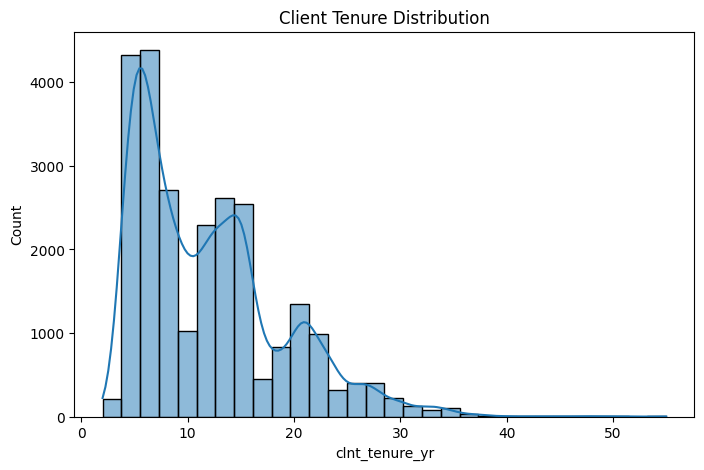

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_active_demo['clnt_tenure_yr'], bins=30, kde=True)
plt.title("Client Tenure Distribution")
plt.show()

# Confirms if users are long-term clients

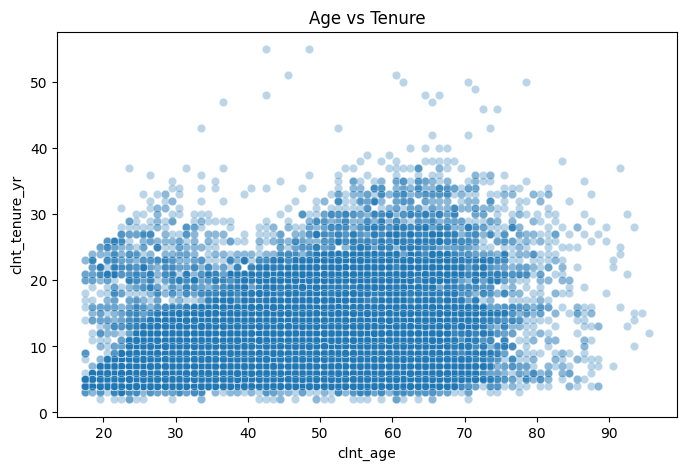

In [79]:
df_demo['age_group'] = pd.cut(df_demo['clnt_age'], bins=bins, labels=labels)

df_demo['age_group'].value_counts(normalize=True)

plt.figure(figsize=(8,5))
sns.scatterplot(data=df_active_demo, x='clnt_age', y='clnt_tenure_yr', alpha=0.3)
plt.title("Age vs Tenure")
plt.show()

# Older clients → longer tenure → core users

High-value clients using the platform: Are high-balance clients active?

<Figure size 800x500 with 0 Axes>

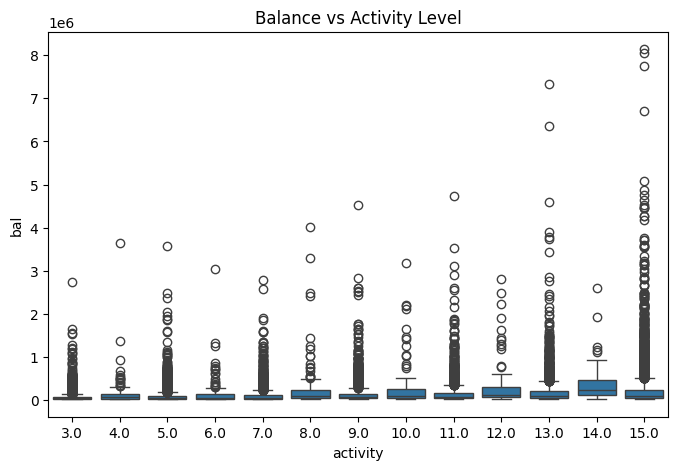

In [80]:
plt.figure(figsize=(8,5))
# create activity field from existing columns (if needed)
df_active_demo['activity'] = df_active_demo['calls_6_mnth'] + df_active_demo['logons_6_mnth']

plt.figure(figsize=(8,5))
sns.boxplot(x='activity', y='bal', data=df_active_demo)
plt.title("Balance vs Activity Level")
plt.show()

Engagement by age: Are older users more engaged?

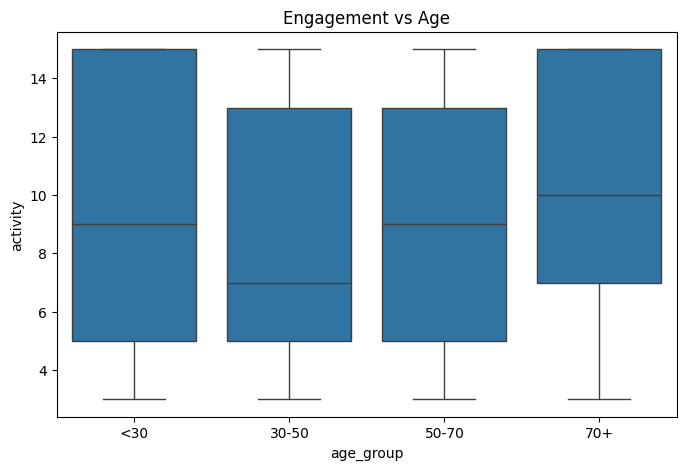

In [81]:
plt.figure(figsize=(8,5))
sns.boxplot(x='age_group', y='activity', data=df_active_demo)
plt.title("Engagement vs Age")
plt.show()

Ternure vs engagement: Measuring loyalty

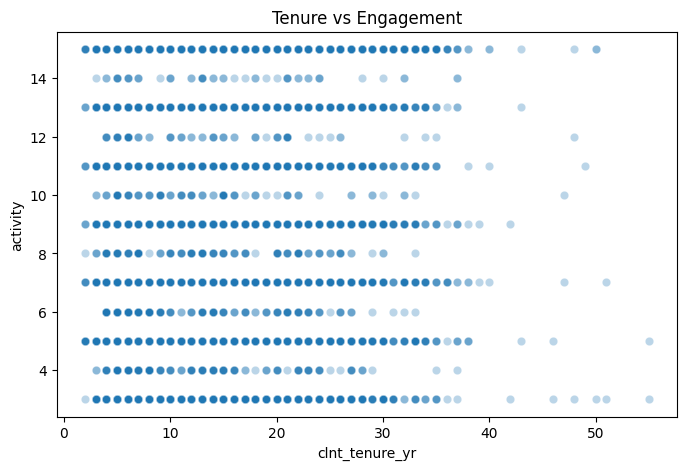

In [82]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_active_demo, x='clnt_tenure_yr', y='activity', alpha=0.3)
plt.title("Tenure vs Engagement")
plt.show()

In [83]:
def segment_client(row):
    if row['clnt_age'] < 30:
        return "Young"
    elif row['clnt_age'] < 60:
        return "Adults"
    else:
        return "Senior"

df_active_demo['segment_client'] = df_active_demo.apply(segment_client, axis=1)
df_active_demo.groupby('segment_client')[['bal', 'activity']].mean()

# Who spends more and who uses more

,bal,activity
segment_client,,
Adults,145308.471205,8.882941
Senior,243047.188322,9.865408
Young,62707.191391,9.505623


In [84]:
summary = df_active_demo.groupby('age_group').agg({
    'client_id': 'count',
    'bal': 'mean',
    'activity': 'mean',
    'clnt_tenure_yr': 'mean'
}).rename(columns={'client_id': 'num_clients'})

summary

,num_clients,bal,activity,clnt_tenure_yr
age_group,,,,
<30,4624,62707.191391,9.505623,8.623919
30-50,9317,120732.791538,8.734249,11.323495
50-70,10149,208159.151714,9.436004,13.499852
70+,1317,271058.850387,10.055429,16.132878


<Figure size 1000x600 with 0 Axes>

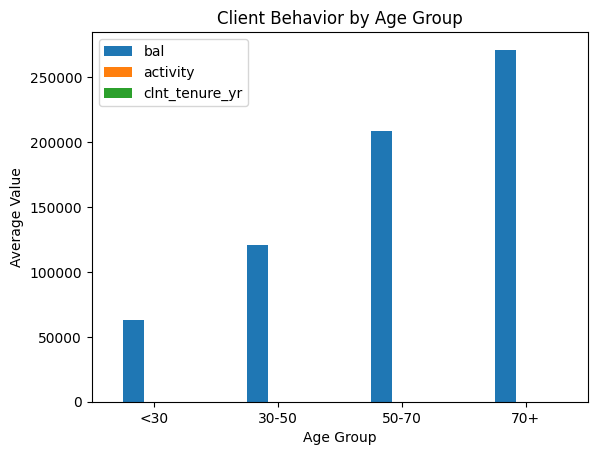

In [85]:
plt.figure(figsize=(10,6))

summary[['bal', 'activity', 'clnt_tenure_yr']].plot(kind='bar')

plt.title("Client Behavior by Age Group")
plt.ylabel("Average Value")
plt.xlabel("Age Group")
plt.xticks(rotation=0)

plt.show()

In [86]:
# More polished version of the above plot

# Rename columns for better readability in the plot
summary_renamed = summary.rename(columns={
    'bal': 'Average Balance',
    'activity': 'Engagement Level',
    'clnt_tenure_yr': 'Client Tenure (Years)',
    'num_clients': 'Number of Clients'
})

# Normalize values for better comparison
summary_norm = summary_renamed.copy()

for col in summary_norm.columns:
    summary_norm[col] = summary_norm[col] / summary_norm[col].max()

# Normalize values for better comparison
summary_norm = summary_renamed.copy()

for col in summary_norm.columns:
    summary_norm[col] = summary_norm[col] / summary_norm[col].max()

<Figure size 1000x600 with 0 Axes>

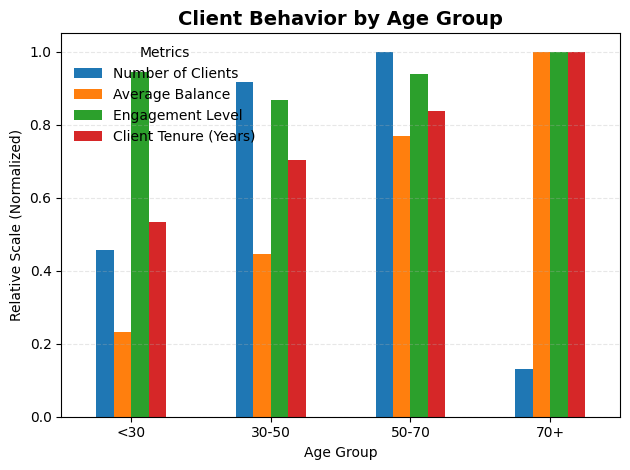

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

summary_norm.plot(kind='bar')

plt.title("Client Behavior by Age Group", fontsize=14, weight='bold')
plt.ylabel("Relative Scale (Normalized)")
plt.xlabel("Age Group")
plt.xticks(rotation=0)

plt.legend(title="Metrics", frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

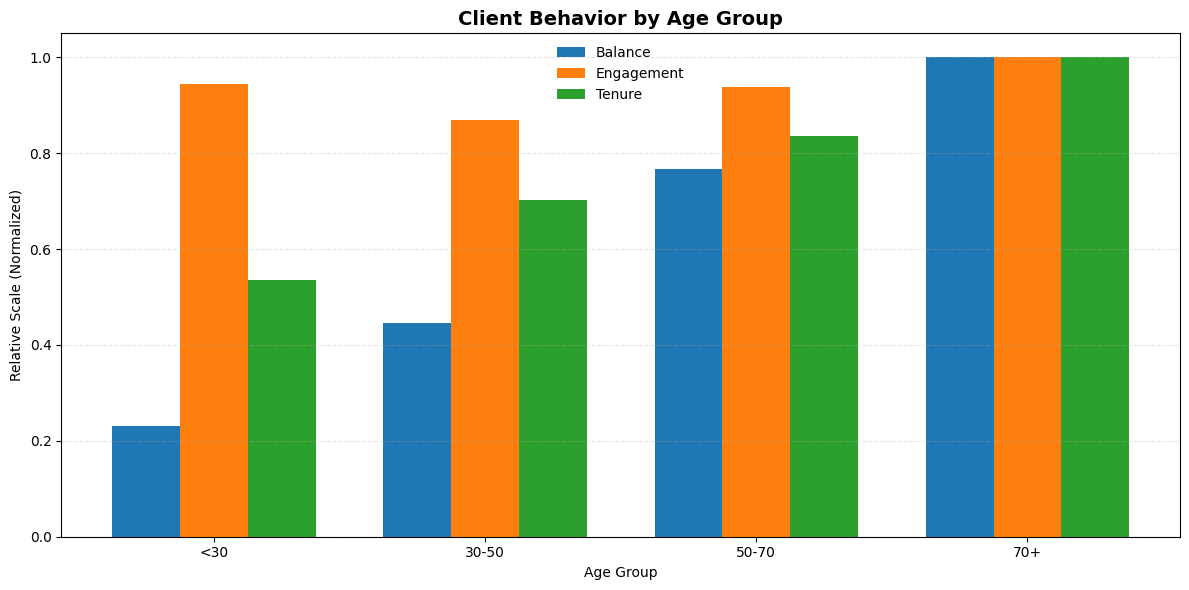

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# Rename for clarity
summary_renamed = summary.rename(columns={
    'bal': 'Average Balance',
    'activity': 'Engagement Level',
    'clnt_tenure_yr': 'Client Tenure (Years)'
}).reset_index()

# Normalize to avoid scale issues
summary_norm = summary_renamed.copy()
cols = ['Average Balance', 'Engagement Level', 'Client Tenure (Years)']

for col in cols:
    summary_norm[col] = summary_norm[col] / summary_norm[col].max()

# Plot setup
x = np.arange(len(summary_norm['age_group']))
width = 0.25

plt.figure(figsize=(12,6))

plt.bar(x - width, summary_norm['Average Balance'], width, label='Balance')
plt.bar(x, summary_norm['Engagement Level'], width, label='Engagement')
plt.bar(x + width, summary_norm['Client Tenure (Years)'], width, label='Tenure')

# Labels
plt.xticks(x, summary_norm['age_group'])
plt.title("Client Behavior by Age Group", fontsize=14, weight='bold')
plt.ylabel("Relative Scale (Normalized)")
plt.xlabel("Age Group")

plt.legend(frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Which group has higher balance 💰
Which group is more engaged 📱
Which group is more loyal ⏳**

### Demographics: Who are the primary clients?

- Age (values ~18 to 80+): Most clients fall roughly between 30 and 65 years old. There are some younger clients (~18–25), but they are less dominant. There are also older clients (65+), but not the majority

- Tenure / relationship length (new vs long-standing): Many entries show tenure values like 10–20+

- Gender (M, F, U): Many entries marked “U” (unknown). Some M/F split, but no obvious dominance. 

Conclusion: The primary users are long-standing clients, not new ones.

### Typical user of the online process:

- Adults (30–65)
- Existing / loyal customer (long tenure)
- Likely financially active (moderate to high balances)

This is important because:
- Digital adoption is not limited to young users
- Your platform is already being used by established clients

### Client Behavior Analysis (Key Insights)

- Are high-value clients using the online process?

Many users have very high balances/income values (in the hundreds of thousands or even millions)
Yes—high-value clients are actively using the platform. The online process is not just for low-value or casual users.

- Is usage linked to tenure?

Tenure: 15–25
Long-term clients are highly engaged digitally. This suggests trust + habit, not just convenience.

- Are younger clients underutilizing the process?

Younger ages (e.g., 18–25) appear less frequently:
Present, but not dominant in usage

Either fewer young clients overall OR younger clients are not the primary users of this specific process.

This could signal: A UX mismatch OR that the service targets more complex needs (typically older clients).

### Engagement levels (frequency / activity)

Many clients show high activity levels. This indicates strong adoption and stickiness.

------


### Additional Important Questions (and Answers)


A. Are loyal customers more digital?
✔ Yes
→ Long-tenure clients are clearly active users

B. Is digital replacing traditional channels?
✔ Likely
→ High engagement + long-standing clients = migration to digital

C. Is there a missed opportunity with younger users?
✔ Probably
→ Younger segment is not dominant → potential growth area

D. Are high-value clients comfortable online?
✔ Yes
→ Strong signal: digital trust is high even for large-value interactions

------


### Final Answer

Primary clients using the online process are adults aged (30–65), long-standing customers with moderate to high financial value. Contrary to common assumptions, the platform is not primarily used by younger or new clients but by experienced and loyal users.

Behaviorally, these clients show high engagement, frequent usage, and strong adoption of the digital process. High-value clients are well represented, indicating trust in the platform. Younger clients appear underrepresented, suggesting a potential opportunity for growth or improved targeting. Overall, digital usage is driven more by customer maturity and relationship length than by age alone.

# Exports for Tableau

In [89]:
%whos

Variable          Type             Data/Info
--------------------------------------------
active_clients    ndarray          25414: 25414 elems, type `int64`, 203312 bytes (198.546875 kb)
bins              list             n=5
col               str              Client Tenure (Years)
cols              list             n=3
config            dict             n=2
df_active_demo    DataFrame        Shape: (25414, 13)
df_demo           DataFrame        Shape: (70609, 10)
df_time_window    DataFrame        Shape: (154358, 17)
file              TextIOWrapper    <_io.TextIOWrapper name='<...>ode='r' encoding='UTF-8'>
labels            list             n=4
np                module           <module 'numpy' from '/Us<...>kages/numpy/__init__.py'>
os                module           <module 'os' (frozen)>
pd                module           <module 'pandas' from '/U<...>ages/pandas/__init__.py'>
plt               module           <module 'matplotlib.pyplo<...>es/matplotlib/pyplot.py'>
segment_client

In [90]:
df_active_demo.head()
df_active_demo.columns

Index(['client_id', 'clnt_tenure_yr', 'clnt_tenure_mnth', 'clnt_age', 'gendr',
       'num_accts', 'bal', 'calls_6_mnth', 'logons_6_mnth', 'age_group',
       'tenure_group', 'activity', 'segment_client'],
      dtype='str')

In [91]:
df_active_demo = df_active_demo.rename(columns={
    "clnt_age": "age",
    "clnt_tenure_yr": "tenure_years"
})

In [92]:
df_active_demo.to_csv("demographics_dataset.csv", index=False)

In [93]:
df_active_demo['client_id'].nunique()

25414